# E-Commerce Sales Data Analysis

## Project Overview
This project analyzes an e-commerce sales dataset to understand patterns in sales performance, profitability, and discount strategies. The goal is to identify key factors affecting profit and provide data-driven recommendations for improving business performance.

The dataset contains over 51,000 orders across multiple product categories including Furniture, Office Supplies, and Technology.

## Importing Required Libraries

We begin by importing the libraries required for data analysis and visualization.

- **Pandas** for data manipulation
- **Matplotlib** for data visualization
- **Seaborn** for advanced visualizations

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

The dataset is loaded into a Pandas DataFrame for analysis.  
We use the `read_csv()` function to import the dataset containing information about sales transactions.

Each row in the dataset represents a single order with details such as product category, sales amount, discount applied, and profit generated.

In [18]:
df = pd.read_csv("../data/Global_Superstore2.csv", encoding="latin1")


## Preview of the Dataset

To understand the structure of the dataset, we display the first few rows using `df.head()`.

This helps us verify that the data has been loaded correctly and gives us an overview of the available columns.

In [19]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


## Dataset Information

Next, we examine the dataset structure using `df.info()`.

This provides important details such as:
- Number of rows and columns
- Data types of each column
- Missing values in the dataset

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  str    
 2   Order Date      51290 non-null  str    
 3   Ship Date       51290 non-null  str    
 4   Ship Mode       51290 non-null  str    
 5   Customer ID     51290 non-null  str    
 6   Customer Name   51290 non-null  str    
 7   Segment         51290 non-null  str    
 8   City            51290 non-null  str    
 9   State           51290 non-null  str    
 10  Country         51290 non-null  str    
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  str    
 13  Region          51290 non-null  str    
 14  Product ID      51290 non-null  str    
 15  Category        51290 non-null  str    
 16  Sub-Category    51290 non-null  str    
 17  Product Name    51290 non-null  str    
 1

## Statistical Summary

The `describe()` function provides a summary of the numerical variables in the dataset, including:

- Mean
- Minimum and maximum values
- Standard deviation
- Quartiles

This helps us understand the distribution of key variables such as sales, profit, quantity, and discount.

In [11]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.00000,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,55190.379428,246.490581,3.476545,0.142908,28.610982,26.375915
std,14806.29199,32063.693350,487.565361,2.278766,0.212280,174.340972,57.296804
min,1.00000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000
25%,12823.25000,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.50000,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.75000,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.00000,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000


## Identifying Loss-Making Orders

In this step, we examine orders where the profit is negative.  
This helps us understand situations where the company is generating sales but still losing money.

By filtering the dataset for transactions with negative profit, we can observe the associated sales values and discount levels for these loss-making orders.

In [12]:
df[df["Profit"] < 0][["Sales", "Discount", "Profit"]].head()

,Sales,Discount,Profit
1,3709.395,0.1,-288.7650
3,2892.510,0.1,-96.5400
9,4297.644,0.4,-1862.3124
30,1696.640,0.2,-148.4600
32,2453.430,0.3,-350.4900


## Impact of Discount on Profit

Discount strategies can significantly affect profitability.  
To understand this relationship, we analyze the average profit associated with different discount levels.

By grouping the dataset by discount levels, we calculate the mean profit for each discount category.

In [13]:
df.groupby("Discount")["Profit"].mean().sort_index()

Discount
0.000      61.039514
0.002     125.762649
0.070     140.990022
0.100      63.683426
0.150      50.602409
0.170      38.317107
0.200      23.552594
0.202     -14.518847
0.250       4.043371
0.270      -4.317213
0.300     -57.899557
0.320     -88.560656
0.350    -116.144693
0.370     -78.462191
0.400     -45.246603
0.402    -109.908138
0.450     -41.610973
0.470     -42.982420
0.500     -97.140158
0.550    -315.067200
0.570    -526.129000
0.600     -81.732147
0.602    -213.279085
0.650    -365.997971
0.700    -104.339576
0.800    -122.203244
0.850   -1534.329000
Name: Profit, dtype: float64

## Visualization: Discount vs Profit

To better understand how discount levels affect profitability, we visualize the relationship between discount percentage and average profit.

By grouping the data by discount levels and plotting the average profit for each level, we can observe whether higher discounts lead to higher or lower profitability.

This visualization helps identify patterns that may not be obvious from raw numerical data.

Matplotlib is building the font cache; this may take a moment.


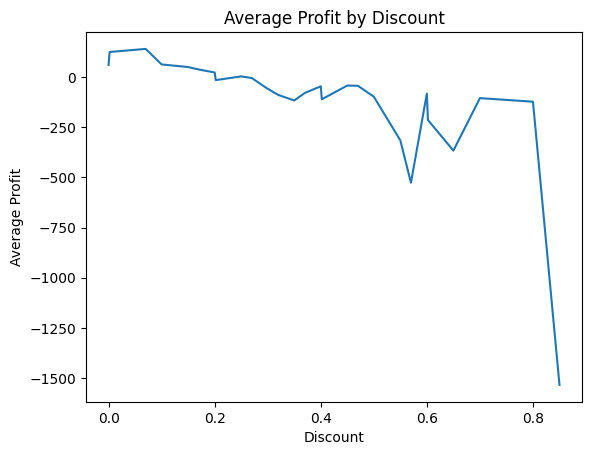

In [ ]:
profit_by_discount = df.groupby("Discount")["Profit"].mean()

profit_by_discount.plot()

plt.title("Average Profit by Discount")
plt.xlabel("Discount")
plt.ylabel("Average Profit")
plt.show()

## Impact of Discount on Sales

In addition to analyzing how discounts affect profit, it is also important to understand how discounts influence sales.

Businesses often offer discounts to increase demand and boost sales volume. By grouping the dataset based on discount levels and calculating the average sales for each discount level, we can observe whether higher discounts are associated with higher sales.

This analysis helps evaluate whether increasing discounts successfully drives more sales.

In [15]:
df.groupby("Discount")["Sales"].mean().sort_index()

Discount
0.000    241.042813
0.002    567.018701
0.070    810.779022
0.100    388.300485
0.150    565.674387
0.170    336.597556
0.200    240.862803
0.202    395.503592
0.250    444.723977
0.270    230.287813
0.300    555.682421
0.320    536.794770
0.350    784.479406
0.370    427.270512
0.400    176.117456
0.402    324.364170
0.450    102.113538
0.470    115.078849
0.500    198.488145
0.550    630.865800
0.570    678.733500
0.600     92.014889
0.602    216.399176
0.650    387.047912
0.700     78.259891
0.800     64.757373
0.850    398.421000
Name: Sales, dtype: float64

## Correlation Analysis

Correlation analysis helps identify relationships between numerical variables.

In this analysis, we focus on the relationship between:
- Discount
- Profit

A negative correlation indicates that as discounts increase, profits tend to decrease.

In [5]:
df[["Discount", "Profit"]].corr()

,Discount,Profit
Discount,1.00000,-0.31649
Profit,-0.31649,1.00000


## Profit by Product Category

To understand which product categories contribute most to profitability, we group the dataset by category and calculate total profit.

This allows us to compare performance across:
- Furniture
- Office Supplies
- Technology

In [6]:
df.groupby("Category")["Profit"].sum().sort_values()

Category
Furniture          285204.72380
Office Supplies    518473.83430
Technology         663778.73318
Name: Profit, dtype: float64

## Sales Performance by Category

To better understand revenue distribution across the business, we analyze total sales generated by each product category.

By grouping the dataset by category and calculating the total sales for each group, we can identify which product categories contribute the most to overall revenue.

This analysis helps highlight the most important business segments and allows companies to focus on categories that drive the majority of sales.

In [7]:
df.groupby("Category")["Sales"].sum().sort_values()



Category
Office Supplies    3.787070e+06
Furniture          4.110874e+06
Technology         4.744557e+06
Name: Sales, dtype: float64

## Profit by Sub-Category

To gain deeper insights, we analyze profit at the sub-category level.

This helps identify specific products that contribute significantly to profits or losses.

For example, the analysis reveals that certain products such as tables generate losses despite having high sales volumes.

In [8]:
df.groupby("Sub-Category")["Profit"].sum().sort_values()

Sub-Category
Tables         -64083.38870
Fasteners       11525.42410
Labels          15010.51200
Supplies        22583.26310
Envelopes       29601.11630
Furnishings     46967.42550
Art             57953.91090
Machines        58867.87300
Paper           59207.68270
Binders         72449.84600
Storage        108461.48980
Accessories    129626.30620
Chairs         140396.26750
Appliances     141680.58940
Bookcases      161924.41950
Phones         216717.00580
Copiers        258567.54818
Name: Profit, dtype: float64

## Sales Performance by Sub-Category

In addition to profit analysis, we examine sales performance across different sub-categories.

This allows us to identify high-revenue products and compare their sales performance with profitability.

In [9]:
df.groupby("Sub-Category")["Sales"].sum().sort_values()


Sub-Category
Labels         7.340403e+04
Fasteners      8.324232e+04
Envelopes      1.709043e+05
Supplies       2.430742e+05
Paper          2.442917e+05
Art            3.720920e+05
Furnishings    3.855783e+05
Binders        4.619115e+05
Accessories    7.492370e+05
Tables         7.570419e+05
Machines       7.790601e+05
Appliances     1.011064e+06
Storage        1.127086e+06
Bookcases      1.466572e+06
Chairs         1.501682e+06
Copiers        1.509436e+06
Phones         1.706824e+06
Name: Sales, dtype: float64

## Data Visualization

Visualizations help communicate insights more effectively.

In this section, we create charts to illustrate key relationships in the data, including:

- Profit by category
- Sales vs profit
- Discount vs profit
- Correlation heatmap

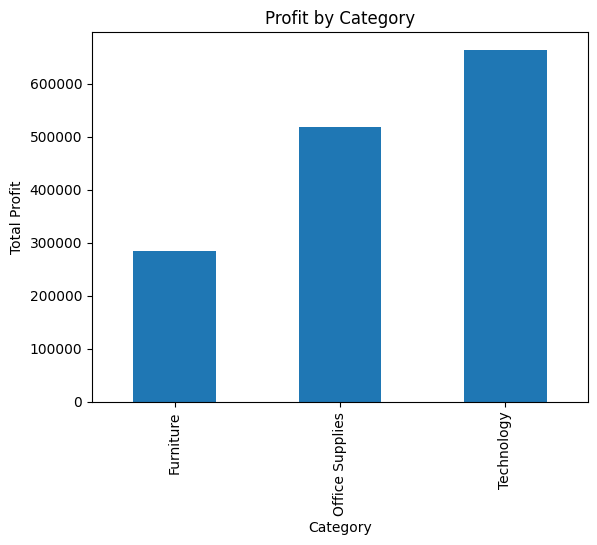

In [ ]:
df.groupby("Category")["Profit"].sum().plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.show()

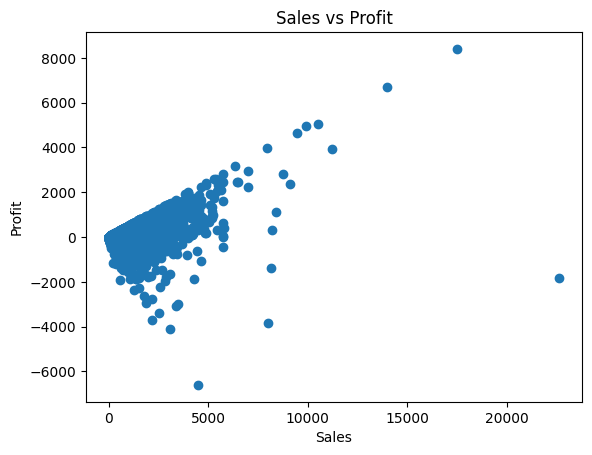

In [11]:
plt.scatter(df["Sales"], df["Profit"])

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()


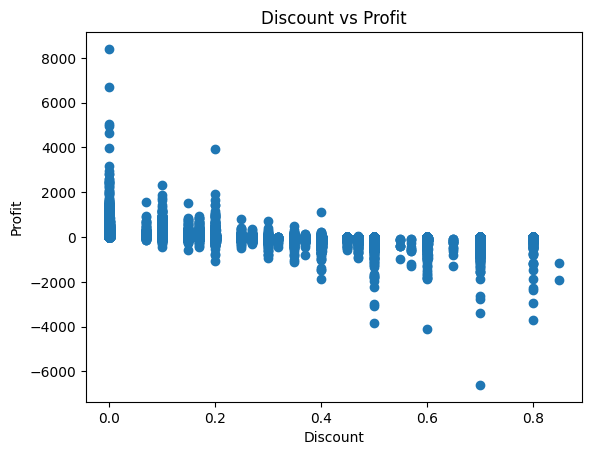

In [12]:
plt.scatter(df["Discount"], df["Profit"])

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

### Correlation Heatmap

To visualize relationships between key numerical variables, we use a heatmap of the correlation matrix.

This visualization helps identify positive and negative relationships between variables such as Sales, Quantity, Discount, and Profit.

In [16]:
corr = df[["Sales", "Quantity", "Discount", "Profit"]].corr()
corr

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.313577,-0.086722,0.484918
Quantity,0.313577,1.000000,-0.019875,0.104365
Discount,-0.086722,-0.019875,1.000000,-0.316490
Profit,0.484918,0.104365,-0.316490,1.000000


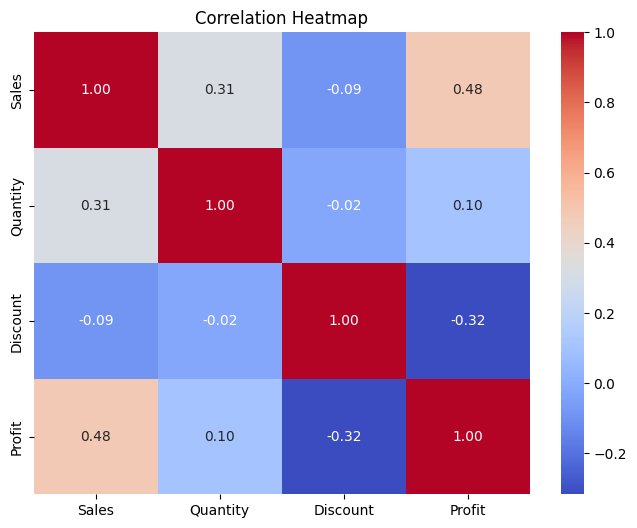

In [20]:
plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

## Key Insights

From the analysis, several important insights emerge:

1. Higher discount levels are associated with lower profitability.
2. Technology products generate the highest profit among all categories.
3. Furniture generates significant sales but relatively low profit.
4. Tables are identified as a major loss-making product despite strong sales.

## Business Recommendations

Based on the analysis, the following recommendations are proposed:

1. Limit high discount strategies that negatively impact profit margins.
2. Reevaluate pricing or cost structure for products such as tables that generate losses.
3. Focus marketing and inventory strategies on high-performing products such as phones and copiers.
4. Monitor discount strategies carefully to balance sales growth with profitability.

## Conclusion

This project demonstrates how data analysis can be used to uncover insights into sales performance and profitability.

By analyzing sales, profit, and discount patterns, we identified key opportunities for improving business strategy. These insights can help the company optimize pricing decisions and focus on more profitable product categories.